In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/batch_10/DN_RHTEST_A3_QUIESCENT_CANONICAL";
data_arrays = reader.fetch_phi2D_data(directory_path, parallelise = True);

Found 2001 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.0s
[Parallel(n_jobs=16)]: Done 464 tasks      | elapsed:    1.8s


Finished compiling data from all files in the directory.


[Parallel(n_jobs=16)]: Done 2001 out of 2001 | elapsed:    4.1s finished


In [ ]:
def plot_zonal_potential_rate_of_change(phi2D_list, dt_diag, effective_radius = 0.7, title_suffix = ""):
	
	zonal_potential = utils.generate_poloidally_averaged_time_series(phi2D_list, effective_radius);
	rates_of_change = np.abs(np.gradient(zonal_potential, dt_diag));
	time_array = np.arange(len(zonal_potential)) * dt_diag;
	
	plt.figure(figsize = (10, 5));
	plt.plot(time_array, rates_of_change, color = "navy", lw = 0.8, label = r"$\partial_t \langle \Phi \rangle_\theta$");
	plt.axhline(y = 0, color = "gray", linestyle = ":", lw = 1.0);
	plt.xlabel("t [GYSELA code units]");
	plt.ylabel(r"|$\partial_t \langle \Phi \rangle_\theta$|");
	plt.title(rf"Rate of change of zonal potential, $\rho$ = {effective_radius}, {title_suffix}");
	plt.legend(frameon = True);
	plt.show();

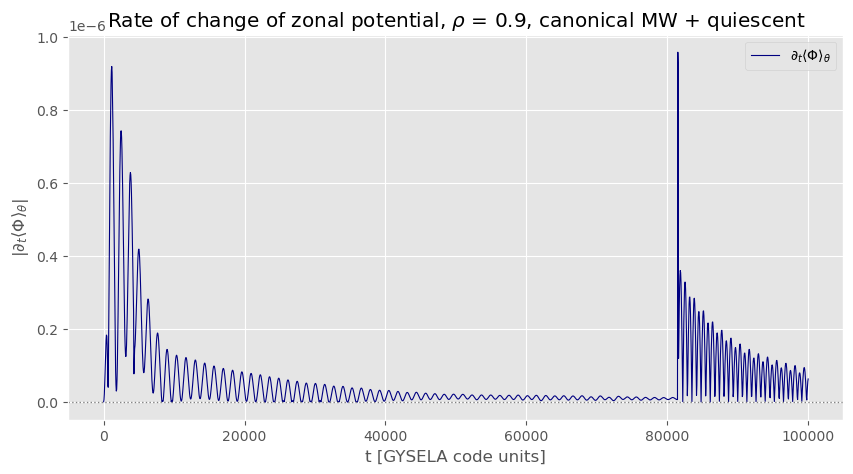

In [23]:
plot_zonal_potential_rate_of_change(data_arrays, dt_diag = 50, effective_radius = 0.9, title_suffix = "canonical MW + quiescent");